In [1]:
import torch
import torchvision
import torchvision.transforms as transforms


import numpy as np

import torch.optim as optim
from sympy.codegen.ast import none
from torch.utils.data import dataloader

from torch.utils.data import random_split, DataLoader

import threading

from agents.Classe_agent import Agent
from topologies.NetworkTopology import NetworkTopology

from models.model import Net,AlexNet
from metrics.metrics import *
from metrics.Classe_model_metrics import ModelMetrics
#from metrics.plot_benchmark import*
from synchronize_weight import*
from training.scrpit_generate_agent import generate_agent
from training.scprit_train_agent import train_agent
from ExperimentRunner import ExperimentRunner

In [2]:
# --- hyperparamètres ---

RANDOM_SEED = 123
BATCH_SIZE = 10
NUM_EPOCHES = 100

MOMENTUM = 0.9
LEARING_RATE = 0.001
SCALE = 0.1
IMG_SIZE = (128, 128)
LATENT_DIM = 10
N_AGENT = 5
k = 5
# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.version
torch.version.cuda
torch.cuda.is_available()

agent_list = generate_agent(BATCH_SIZE,N_AGENT,DEVICE)


C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555], Sum: 27775


# Communication Graphe

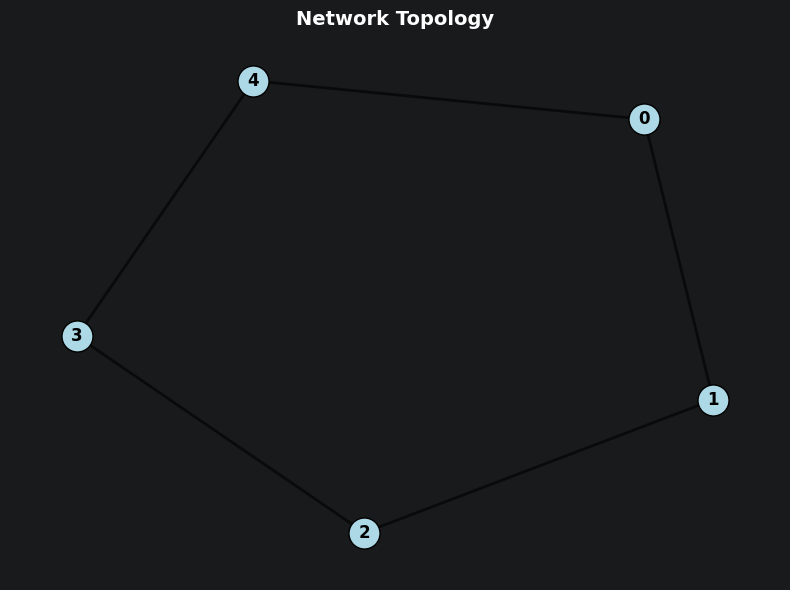

In [3]:
graph = NetworkTopology.cycle_graph(len(agent_list))

for agent_id, agent in enumerate(agent_list):
    graph.add_node(agent_id, agent=agent)

NetworkTopology.visualize_graph(graph)

# ──────────────────────────────────────────────────────────────
# Wrapper pour normaliser les signatures
# (certaines fns n'utilisent pas graph ou k)
# ──────────────────────────────────────────────────────────────
def avg_wrapper(agent_list, graph, k):
    synchronize_models_average(agent_list)

def cycle_wrapper(agent_list, graph, k):
    synchronize_models_cycle(agent_list)

def consensus_wrapper(agent_list, graph, k):
    consensu_algortyme(agent_list, graph, K=k)

def topology_wrapper(agent_list, graph, k):
    synchronize_with_topology(agent_list, graph)

def Topology_ring_k_wrapper(agent_list, graph, k):
    synchronize_models_cycle_k(agent_list,k,N_AGENT)
# ──────────────────────────────────────────────────────────────
# Dictionnaire des méthodes à comparer
# ──────────────────────────────────────────────────────────────
COMMUNICATION_METHODS = {
    "Average Global"            : avg_wrapper,
    "Hamiltonian cycle"         : cycle_wrapper,
    f"Consensus (K=f{k})"       : consensus_wrapper,
    "Topology (Ring)"           : topology_wrapper,
    "Topology (Ring(K=/f{k}))"  : Topology_ring_k_wrapper,
}



In [11]:
for communication_model in COMMUNICATION_METHODS:
    print(COMMUNICATION_METHODS[communication_model])

<function avg_wrapper at 0x000001A0D210AE50>
<function cycle_wrapper at 0x000001A0DC4392D0>
<function consensus_wrapper at 0x000001A0DC3F7B60>
<function topology_wrapper at 0x000001A0DC3F7530>
<function Topology_ring_k_wrapper at 0x000001A0DC3F75E0>


In [ ]:
from training.benchmark import benchmark_sequential
from training.plot_benchmark_results import plot_all_benchmark_metrics
from training.plot_benchmark_results import print_benchmark_summary

results = benchmark_sequential(
    communication_methods=COMMUNICATION_METHODS,
    num_epochs=NUM_EPOCHES,
    graph=graph,
    k=k,
    BATCH_SIZE=BATCH_SIZE,
    N_AGENT=N_AGENT,
    DEVICE=DEVICE,
)

# ── Résultats ──────────────────────────────────────────────
print_benchmark_summary(results)
plot_all_benchmark_metrics(results)

cwd = C:\Users\flofl\PycharmProjects\IA_A_à_Z
file = C:\Users\flofl\PycharmProjects\IA_A_à_Z\training\benchmark.py

  RUN — méthode : Average Global
0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555], Sum: 27775
  [Epoch 1/100] threads lancés …
Agent 3 start
Agent 4 start
Agent 0 start
Agent 2 start
Agent 1 start
Model3 - Acc:13.38 % - Loss:2.2979499292373657 %
Model4 - Acc:11.44 % - Loss:2.298991963624954 %
Model0 - Acc:10.87 % - Loss:2.3017555553913116 %
Model2 - Acc:11.87 % - Loss:2.298902713537216 %
Model1 - Acc:14.22 % - Loss:2.2672193439006807 %
  [Epoch 2/100] threads lancés …
Agent 4 start
Agent 3 start
Agent 1 start
Agent 2 start
Agent 0 start
Model4 - Acc:9.82 % - Loss:2.3027146079540253 %
Model1 - Acc:10.01 % - Loss:2.3026036121845244 %
Model3 - Acc:10.26 % - Loss:2.302501129865646 %
Model2 - Acc:9.85 % - Loss:2.3029256756305694 %
Model0 - Acc:9.91 % - Loss:2.30276860165596 %
  [Epoch 3/100] threads lancés …
Agent 2 start
Agent 4 start
Agent 1 start
Agent 3 start
Ag

Average Global
0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555], Sum: 27775
Epoch 1/10
Agent 0 start
Agent 1 start
Agent 3 start
Agent 2 start
Agent 4 start
Model0 - Acc:12.99 % - Loss:2.2976750802993773 %
Model1 - Acc:12.89 % - Loss:2.2867109944820405 %
Model3 - Acc:12.96 % - Loss:2.2961869597435 %
Model2 - Acc:16.05 % - Loss:2.2355653010606766 %
Model4 - Acc:14.07 % - Loss:2.2929019112586975 %
Epoch 2/10
Agent 4 start
Agent 3 start
Agent 0 start
Agent 1 start
Agent 2 start
Model4 - Acc:13.31 % - Loss:2.3009524683952334 %
Model0 - Acc:10.84 % - Loss:2.301093677043915 %
Model1 - Acc:11.32 % - Loss:2.3007868847846984 %
Model2 - Acc:11.79 % - Loss:2.3012314546108246 %
Model3 - Acc:11.71 % - Loss:2.3010654575824736 %
Epoch 3/10
Agent 4 start
Agent 0 start
Agent 1 start
Agent 3 start
Agent 2 start
Model0 - Acc:17.17 % - Loss:2.24839841401577 %
Model1 - Acc:16.98 % - Loss:2.248485392451286 %
Model3 - Acc:18.44 % - Loss:2.2454756109714507 %
Model2 - Acc:17.43 % - Loss:2.2470163033

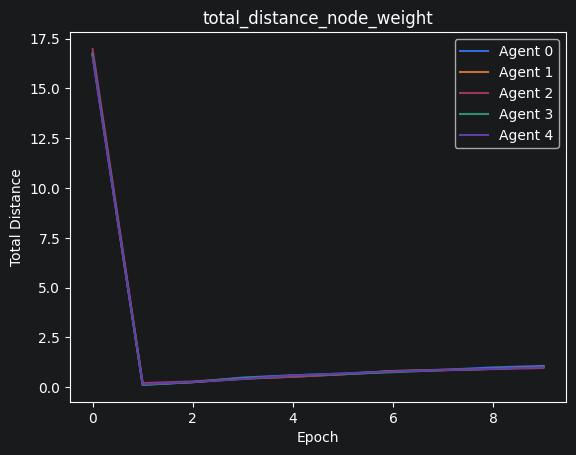

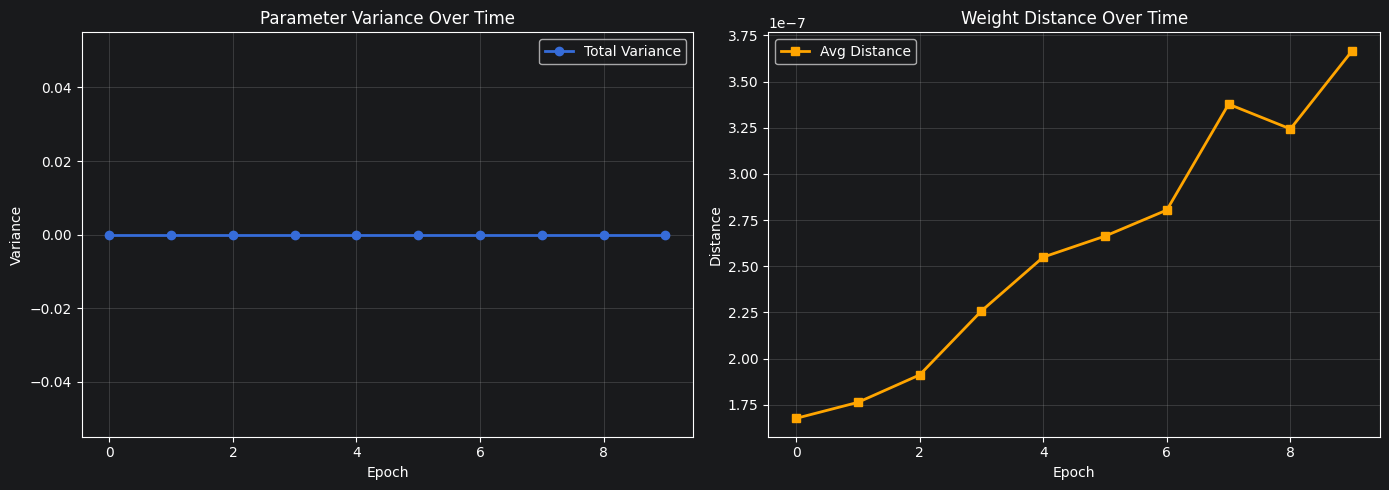


Agent 0
conv1.weight                   L2 distance = 0.000000
conv1.bias                     L2 distance = 0.000000
conv2.weight                   L2 distance = 0.000000
conv2.bias                     L2 distance = 0.000000
fc1.weight                     L2 distance = 0.000000
fc1.bias                       L2 distance = 0.000000
fc2.weight                     L2 distance = 0.000000
fc2.bias                       L2 distance = 0.000000
fc3.weight                     L2 distance = 0.000000
fc3.bias                       L2 distance = 0.000000
Distance totale = 0.000000

Agent 1
conv1.weight                   L2 distance = 0.000000
conv1.bias                     L2 distance = 0.000000
conv2.weight                   L2 distance = 0.000000
conv2.bias                     L2 distance = 0.000000
fc1.weight                     L2 distance = 0.000000
fc1.bias                       L2 distance = 0.000000
fc2.weight                     L2 distance = 0.000000
fc2.bias                       L2 dis

In [ ]:
from training.scprit_train_agent import train_agent

agent_list_communication_model = []

for communication_model in COMMUNICATION_METHODS:
    print(communication_model)
    agent_list = generate_agent(BATCH_SIZE,N_AGENT,DEVICE)
    metrics = train_agent(agent_list,NUM_EPOCHES,graph,k,COMMUNICATION_METHODS[communication_model])
    agent_list_communication_model.append(agent_list[0])
    plot_all_agent_node_weight_metric(agent_list)
    metrics.plot_history()
    node_weight_metric(agent_list)


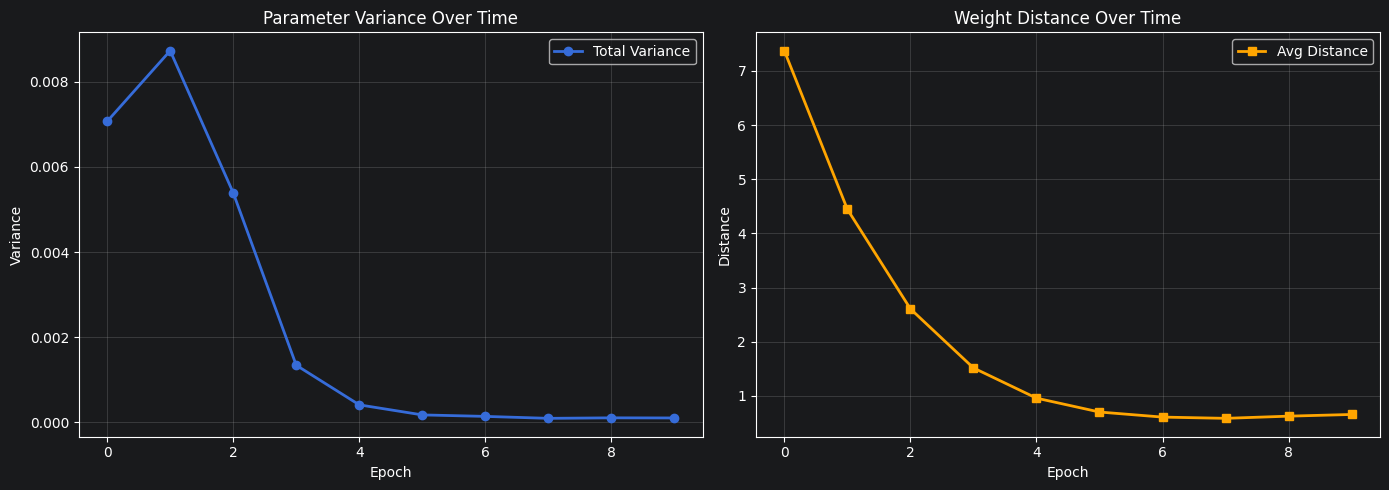

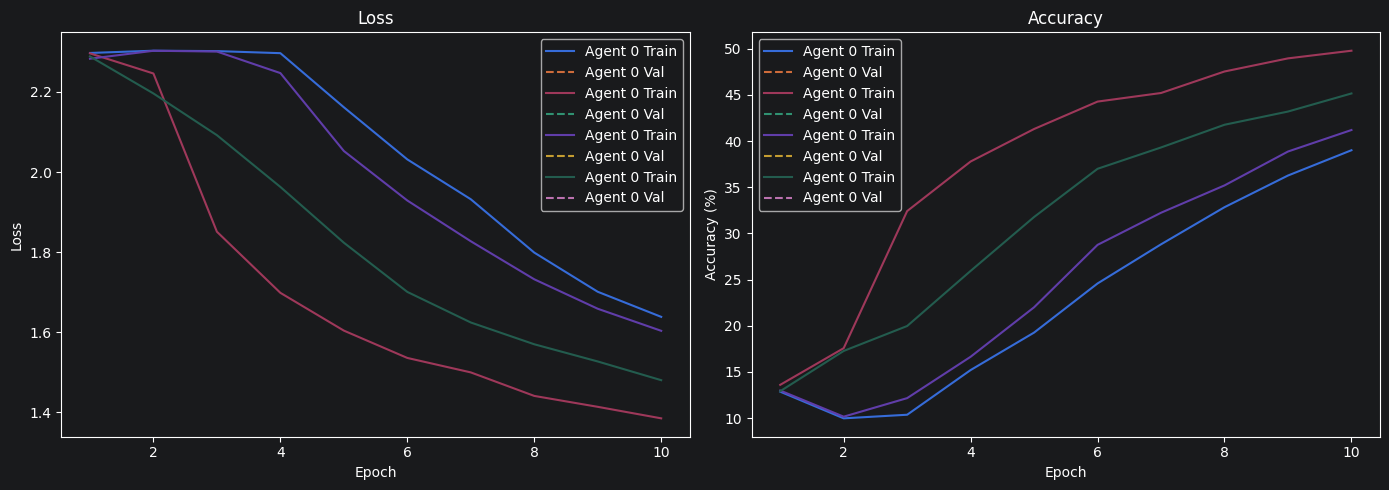

In [18]:
plot_all_agents_metrics(agent_list_communication_model)

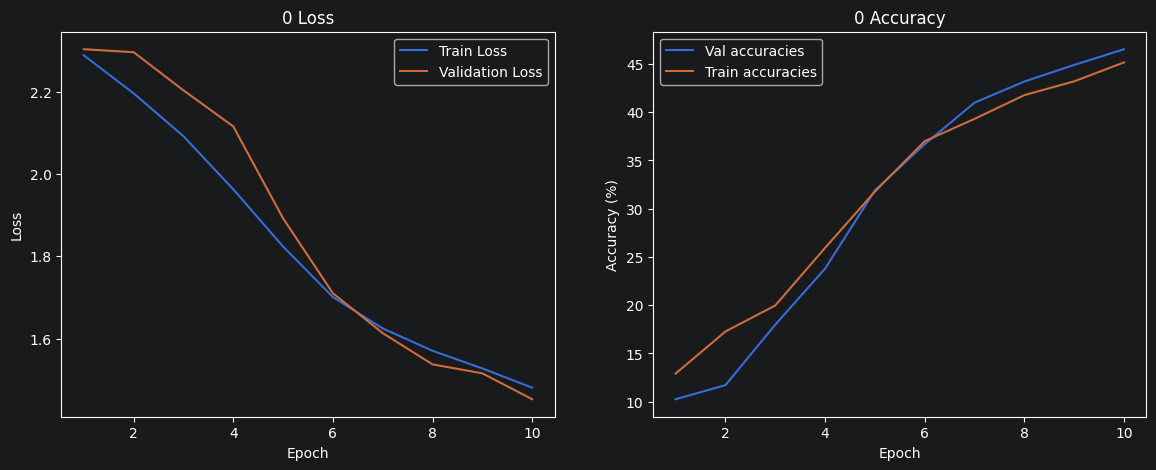

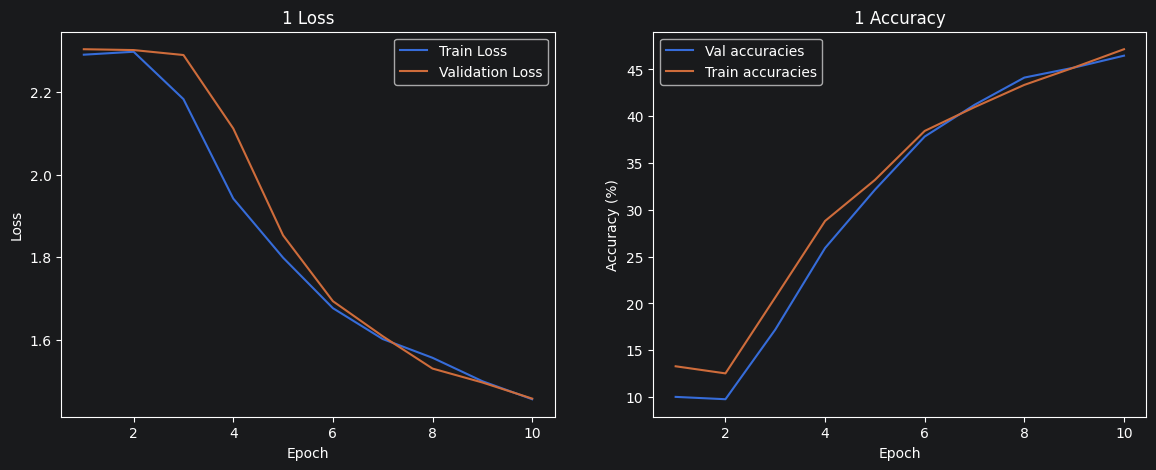

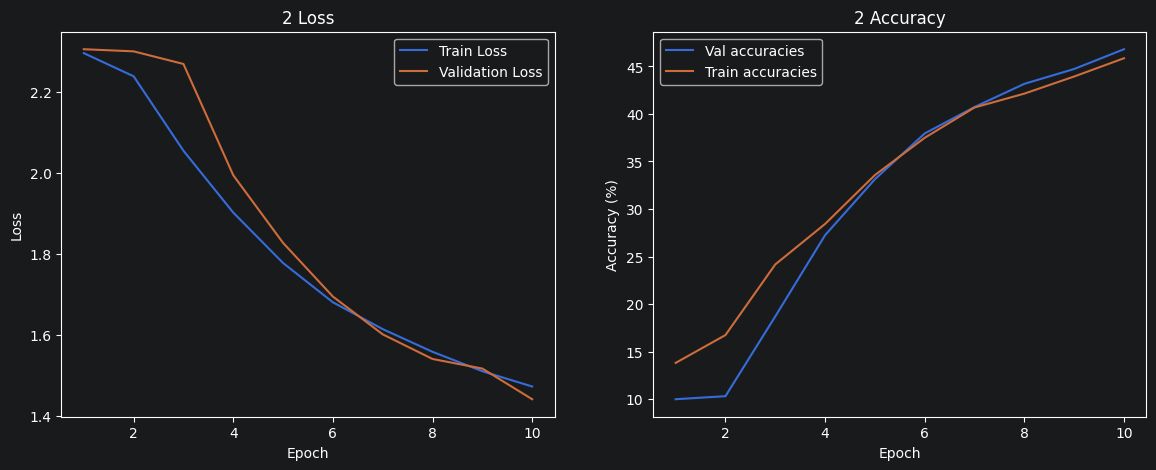

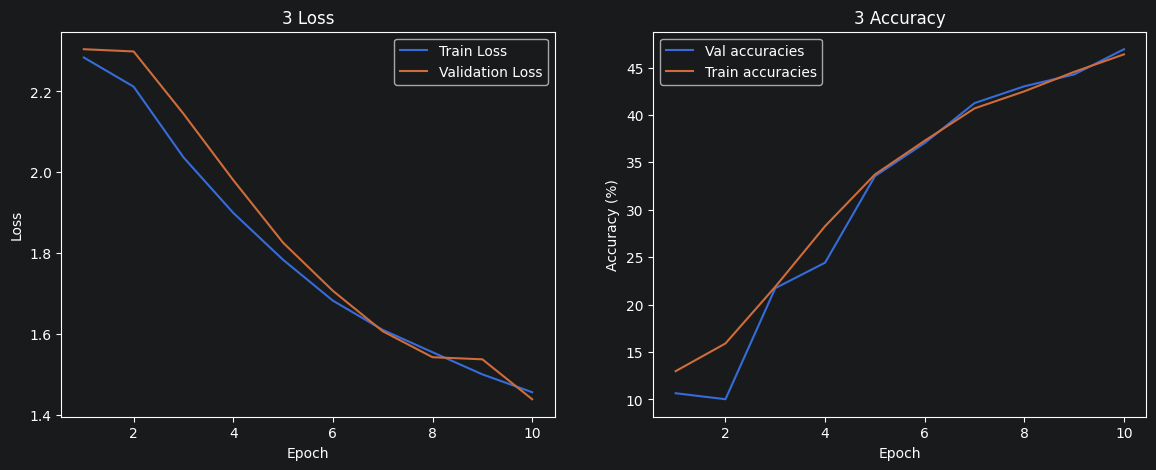

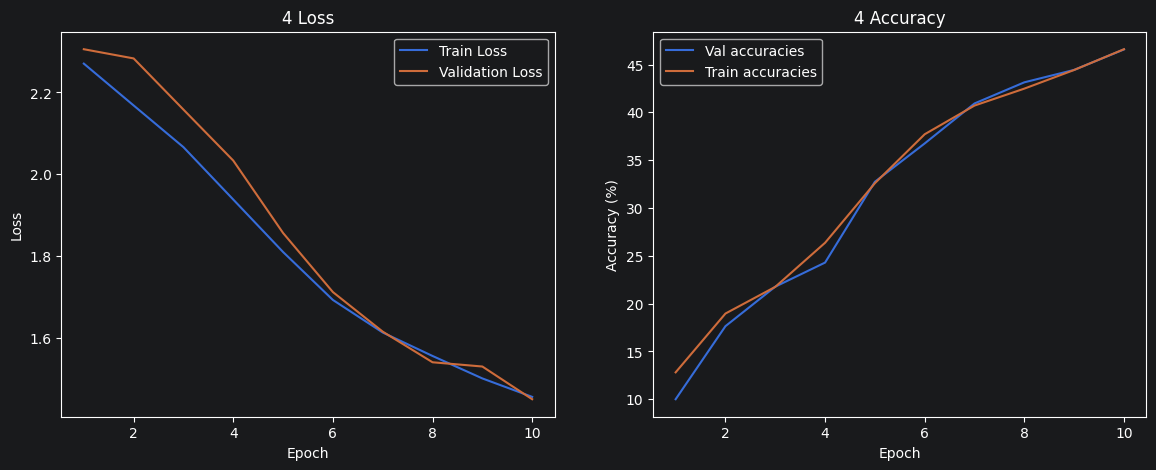

In [19]:
for agent in agent_list:

    agent.plot_metrics()


Agent 0
conv1.weight                   L2 distance = 0.090668
conv1.bias                     L2 distance = 0.026849
conv2.weight                   L2 distance = 0.242937
conv2.bias                     L2 distance = 0.014091
fc1.weight                     L2 distance = 0.647147
fc1.bias                       L2 distance = 0.008948
fc2.weight                     L2 distance = 0.222414
fc2.bias                       L2 distance = 0.014492
fc3.weight                     L2 distance = 0.073451
fc3.bias                       L2 distance = 0.009263
Distance totale = 1.350259

Agent 1
conv1.weight                   L2 distance = 0.135291
conv1.bias                     L2 distance = 0.038106
conv2.weight                   L2 distance = 0.316552
conv2.bias                     L2 distance = 0.018611
fc1.weight                     L2 distance = 0.868571
fc1.bias                       L2 distance = 0.011792
fc2.weight                     L2 distance = 0.313005
fc2.bias                       L2 dis

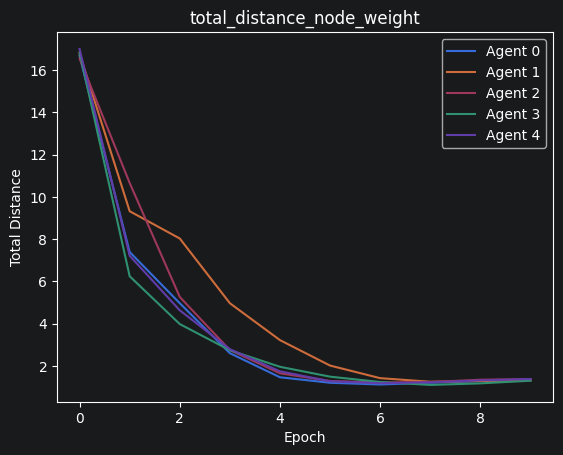

In [14]:
for agent in agent_list:
    print("Agent",agent.id)
    print(agent.val_losses)
    print(agent.val_accuracies)

Agent 0
[2.305119649171829, 2.302758082151413, 2.3018102436065675, 2.2947319538593294, 2.1586101331710816, 2.0202702475786207, 1.8904044127464295, 1.789566971898079, 1.6728246143460275, 1.608958977341652]
[10.0, 10.0, 13.29, 15.11, 20.03, 25.44, 30.73, 34.85, 38.71, 40.76]
Agent 1
[2.304589174747467, 2.3027424552440645, 2.301819096326828, 2.2947720589637757, 2.158840028166771, 2.0203251011371615, 1.8902027515172959, 1.7896384028196335, 1.6723584297299385, 1.607698366999626]
[10.0, 10.0, 14.04, 15.07, 20.04, 25.49, 30.93, 34.85, 38.79, 40.84]
Agent 2
[2.3058548002243042, 2.302727950334549, 2.3018116772174837, 2.2946962826251984, 2.158923611998558, 2.0205641169548034, 1.890019845366478, 1.7898259873390199, 1.672233254134655, 1.6052132020592689]
[9.99, 10.0, 13.8, 14.98, 20.02, 25.45, 30.82, 34.92, 38.8, 40.94]
Agent 3
[2.304427543640137, 2.302717181444168, 2.301797329902649, 2.2946089360713957, 2.1587441389560698, 2.0206734281778336, 1.8901250556707383, 1.7898396862745285, 1.672579335570